In [2]:
# ─── Standalone prelude ───────────────────────────────────────────────────────
import os, json

RESULTS_STORE = "experiments_v5/results_store.json"   # adjust if run from elsewhere
VIS_DIR       = "visualisations_paper"
os.makedirs(VIS_DIR, exist_ok=True)

def load_results():
    with open(RESULTS_STORE) as f:
        return json.load(f)

print(f"Store  : {os.path.abspath(RESULTS_STORE)}")
print(f"Records: {len(load_results())}")
print(f"Figures: {os.path.abspath(VIS_DIR)}")

# ─── Readable split labels for figures ────────────────────────────────────────
ACTIVITY_MAP = {1:"lying", 2:"sitting", 3:"standing", 4:"walking", 5:"running",
                6:"cycling", 7:"Nordic walk", 9:"watching TV", 10:"computer work",
                11:"car driving", 12:"asc stairs", 13:"desc stairs",
                16:"vacuum", 17:"ironing", 18:"folding", 19:"house clean",
                20:"soccer", 24:"rope jump"}

def pretty(split_id):
    return "\n".join(ACTIVITY_MAP[int(i)] for i in split_id.split("_"))

Store  : /Users/anikghosh/Desktop/test/Zero Shot Learning/experiments_v5/results_store.json
Records: 10
Figures: /Users/anikghosh/Desktop/test/Zero Shot Learning/visualisations_paper


DROPPED llm|1_4_11_19|seed42|195dc37466: zero test support for class(es) ['11']; macro F1 is capped below 1.0 and the probe is undefined.

Aggregating 9 splits (llm), t(0.975,8) = 2.306

TABLE 1  Macro F1 by split
  split              n     A1     A2     A3
  1_10_12_16       387   0.54   0.50   0.48
  1_10_12_19       489   0.34   0.48   0.48
  1_2_3_4          202   0.01   0.06   0.14
  2_12_13_19       231   0.20   0.24   0.50
  2_12_17_20       220   0.23   0.56   0.50
  3_5_10_13        369   0.42   0.44   0.41
  4_6_7_24         195   0.07   0.43   0.30
  5_10_13_16       367   0.30   0.31   0.36
  5_13_16_18       194   0.34   0.38   0.33
  Macro F1
    A1: 0.27 +/- 0.17  [0.14, 0.40]
    A2: 0.38 +/- 0.15  [0.26, 0.50]
    A3: 0.39 +/- 0.12  [0.30, 0.48]
  Balanced acc
    A1: 0.37 +/- 0.21  [0.20, 0.53]
    A2: 0.42 +/- 0.17  [0.29, 0.56]
    A3: 0.45 +/- 0.18  [0.31, 0.58]
  Accuracy
    A1: 0.37 +/- 0.19  [0.23, 0.52]
    A2: 0.49 +/- 0.17  [0.36, 0.62]
    A3: 0.48 +/- 0.15

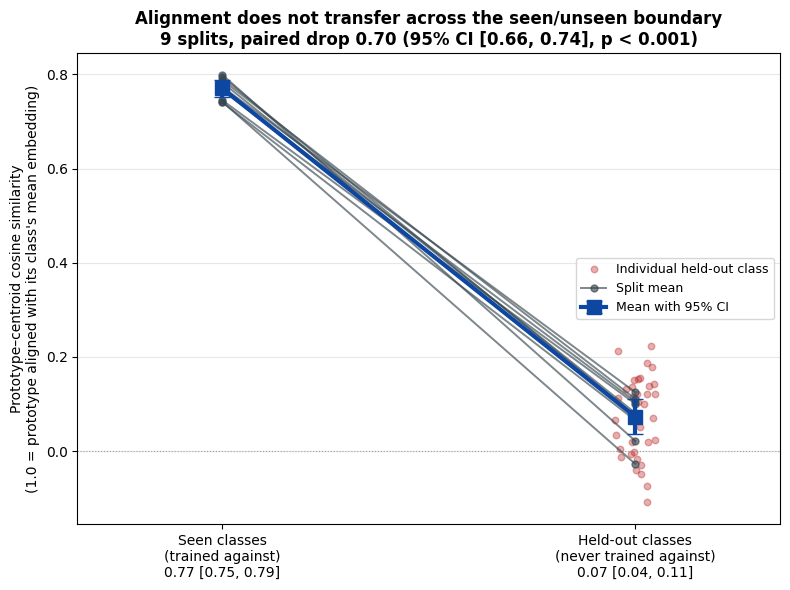

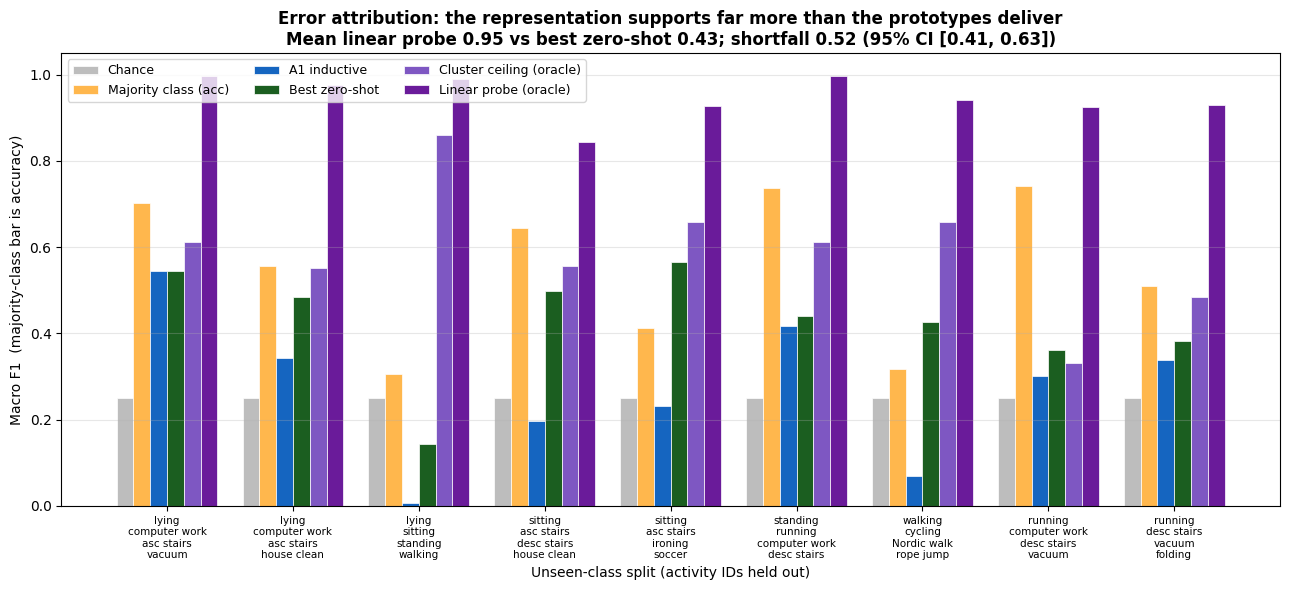


Saved to visualisations_paper: seen_vs_unseen_alignment.png, error_attribution.png


In [3]:
# ─── Cross-split aggregation: paper figures and tables ────────────────────────
# Reads every record in the store, groups by protocol-excluding-split, and emits
# the two aggregate figures plus the numbers behind the results tables.
import numpy as np, matplotlib.pyplot as plt
from scipy import stats

AGG_PROTOTYPE_SET = "llm"
EXCLUDE_ZERO_SUPPORT = True     # drop splits where an unseen class has no test windows

def _comparable(store, cfg):
    """Group by everything except the split, since the protocol hash includes it."""
    out = []
    for k, r in store.items():
        if r["prototype_set"] != cfg:
            continue
        p = dict(r["protocol"]); p.pop("unseen"); p.pop("val_unseen")
        out.append((k, r, tuple(sorted(p.items()))))
    if not out:
        return []
    from collections import Counter
    sig = Counter(s for _, _, s in out).most_common(1)[0][0]
    odd = [k for k, _, s in out if s != sig]
    if odd:
        print(f"Excluded, protocol differs from the majority: {odd}")
    return [(k, r) for k, r, s in out if s == sig]

recs = _comparable(load_results(), AGG_PROTOTYPE_SET)

dropped = []
if EXCLUDE_ZERO_SUPPORT:
    keep = []
    for k, r in recs:
        zero = [c for c, n in r["test_support"].items() if n == 0]
        (dropped if zero else keep).append((k, r) if not zero else (k, zero))
        if zero:
            print(f"DROPPED {k}: zero test support for class(es) {zero}; "
                  f"macro F1 is capped below 1.0 and the probe is undefined.")
    recs = keep

recs.sort(key=lambda kr: kr[0])
labels = [k.split("|")[1] for k, _ in recs]
R      = [r for _, r in recs]
n      = len(R)
tcrit  = stats.t.ppf(0.975, n - 1)
print(f"\nAggregating {n} splits ({AGG_PROTOTYPE_SET}), t(0.975,{n-1}) = {tcrit:.3f}")

def ci(v):
    v = np.asarray(v, float); m = v.mean(); s = v.std(ddof=1)
    h = tcrit * s / np.sqrt(len(v))
    return m, s, m - h, m + h

f1    = {a: [r[a]["macro_f1"] for r in R] for a in ("A1", "A2", "A3")}
bal   = {a: [r[a]["bal_acc"]  for r in R] for a in ("A1", "A2", "A3")}
acc   = {a: [r[a]["acc"]      for r in R] for a in ("A1", "A2", "A3")}
probe = [r["probe_macro_f1"]  for r in R]
ceil  = [r["ceiling_macro_f1"] for r in R]
maj   = [r["majority_acc"]    for r in R]
gap   = [r["gap_mean"]        for r in R]
own   = [float(np.mean(list(r["unseen_own_cos"].values()))) for r in R]
best  = [max(r["A1"]["macro_f1"], r["A2"]["macro_f1"], r["A3"]["macro_f1"]) for r in R]

# ── Table 1: per split ────────────────────────────────────────────────────────
print("\nTABLE 1  Macro F1 by split")
print(f"  {'split':14s} {'n':>5s} {'A1':>6s} {'A2':>6s} {'A3':>6s}")
for i, s in enumerate(labels):
    print(f"  {s:14s} {R[i]['n_test']:>5d} "
          f"{f1['A1'][i]:>6.2f} {f1['A2'][i]:>6.2f} {f1['A3'][i]:>6.2f}")
for name, d in [("Macro F1", f1), ("Balanced acc", bal), ("Accuracy", acc)]:
    print(f"  {name}")
    for a in ("A1", "A2", "A3"):
        m, s, lo, hi = ci(d[a])
        print(f"    {a}: {m:.2f} +/- {s:.2f}  [{lo:.2f}, {hi:.2f}]")
m, s, lo, hi = ci(maj); print(f"  Majority-class accuracy: {m:.2f} +/- {s:.2f}")
print(f"  Splits where majority accuracy beats every approach: "
      f"{sum(1 for i in range(n) if maj[i] > max(acc[a][i] for a in acc))}/{n}")

# ── Table 2: paired differences ───────────────────────────────────────────────
print("\nTABLE 2  Paired differences in macro F1")
for a, b in [("A2", "A1"), ("A3", "A1"), ("A3", "A2")]:
    d = np.array(f1[a]) - np.array(f1[b]); m, s, lo, hi = ci(d)
    p  = stats.ttest_rel(f1[a], f1[b]).pvalue
    pw = stats.wilcoxon(f1[a], f1[b]).pvalue
    print(f"  {a}-{b}: {m:+.2f}  [{lo:+.2f}, {hi:+.2f}]  t-test p={p:.3f}  "
          f"Wilcoxon p={pw:.3f}  wins {(d > 0).sum()}/{n}")

# ── Table 3: oracle diagnostics ───────────────────────────────────────────────
print("\nTABLE 3  Oracle diagnostics")
for name, v in [("Linear probe", probe), ("Cluster ceiling", ceil),
                ("Best zero-shot", best), ("A1 inductive", f1["A1"])]:
    m, s, lo, hi = ci(v)
    print(f"  {name:16s} {m:.2f} +/- {s:.2f}  [{lo:.2f}, {hi:.2f}]  "
          f"range [{min(v):.2f}, {max(v):.2f}]")
for lbl, x in [("probe - best", best), ("probe - A1", f1["A1"])]:
    d = np.array(probe) - np.array(x); m, s, lo, hi = ci(d)
    print(f"  {lbl}: {m:.2f}  [{lo:.2f}, {hi:.2f}]  p={stats.ttest_rel(probe, x).pvalue:.1e}")

# ── Alignment and beta summary ────────────────────────────────────────────────
m, s, lo, hi = ci(gap);  print(f"\nSeen-class gap   : {m:.2f} +/- {s:.2f}  [{lo:.2f}, {hi:.2f}]")
m, s, lo, hi = ci(own);  print(f"Unseen own-cosine: {m:.2f} +/- {s:.2f}  [{lo:.2f}, {hi:.2f}]")
d = np.array(gap) - np.array(own); m, s, lo, hi = ci(d)
print(f"Paired drop      : {m:.2f}  [{lo:.2f}, {hi:.2f}]  "
      f"p={stats.ttest_rel(gap, own).pvalue:.1e}")
_all = [v for r in R for v in r["unseen_own_cos"].values()]
print(f"  {len(_all)} class instances, {sum(1 for v in _all if v < 0)} negative, "
      f"min {min(_all):.2f}, max {max(_all):.2f}")

hits, betas = 0, []
for r in R:
    for b, g in [(r["beta_a2"], r["beta_grid_a2"]), (r["beta_a3"], r["beta_grid_a3"])]:
        betas.append(b)
        hits += abs(b - g[0]) < 1e-9 or abs(b - g[-1]) < 1e-9
print(f"Beta at a grid endpoint in {hits}/{2*n} selections; "
      f"selected values span {min(betas):.4f} to {max(betas):.2f}")

# ══ FIGURE: seen vs unseen alignment ══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.RandomState(0)
for i, r in enumerate(R):
    vals = list(r["unseen_own_cos"].values())
    ax.scatter(np.full(len(vals), 1) + rng.uniform(-.05, .05, len(vals)), vals,
               s=22, color="#B71C1C", alpha=.35, zorder=2,
               label="Individual held-out class" if i == 0 else None)
    ax.plot([0, 1], [gap[i], own[i]], color="#37474F", alpha=.65, lw=1.4,
            marker="o", ms=5, zorder=3,
            label="Split mean" if i == 0 else None)
mg, _, lg, hg = ci(gap); mo, _, lo_, ho = ci(own)
ax.errorbar([0, 1], [mg, mo], yerr=[[mg - lg, mo - lo_], [hg - mg, ho - mo]],
            color="#0D47A1", lw=3, marker="s", ms=10, capsize=6, zorder=4,
            label="Mean with 95% CI")
ax.axhline(0, color="#9E9E9E", lw=.8, ls=":")
ax.set_xticks([0, 1]); ax.set_xlim(-.35, 1.35)
ax.set_xticklabels([f"Seen classes\n(trained against)\n{mg:.2f} [{lg:.2f}, {hg:.2f}]",
                    f"Held-out classes\n(never trained against)\n{mo:.2f} [{lo_:.2f}, {ho:.2f}]"],
                   fontsize=10)
ax.set_ylabel("Prototype–centroid cosine similarity\n"
              "(1.0 = prototype aligned with its class's mean embedding)", fontsize=10)
ax.set_title(f"Alignment does not transfer across the seen/unseen boundary\n"
             f"{n} splits, paired drop {np.mean(d):.2f} "
             f"(95% CI [{ci(d)[2]:.2f}, {ci(d)[3]:.2f}], p < 0.001)",
             fontweight="bold", fontsize=12)
ax.grid(True, axis="y", alpha=.3); ax.legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "seen_vs_unseen_alignment.png"), dpi=200,
            bbox_inches="tight")
plt.show(); plt.close()

# ══ FIGURE: error attribution ═════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
series = [("Chance", [0.25] * n, "#BDBDBD"),
          ("Majority class (acc)", maj, "#FFB74D"),
          ("A1 inductive", f1["A1"], "#1565C0"),
          ("Best zero-shot", best, "#1B5E20"),
          ("Cluster ceiling (oracle)", ceil, "#7E57C2"),
          ("Linear probe (oracle)", probe, "#6A1B9A")]
x = np.arange(n); w = 0.8 / len(series)
for j, (nm, v, col) in enumerate(series):
    ax.bar(x + (j - (len(series) - 1) / 2) * w, v, w, label=nm, color=col,
           edgecolor="white", linewidth=.5)
ax.set_xticks(x)
ax.set_xticklabels([pretty(s) for s in labels], rotation=0, ha="center", fontsize=7.5)
ax.set_xlabel("Unseen-class split (activity IDs held out)", fontsize=10)
ax.set_ylabel("Macro F1  (majority-class bar is accuracy)", fontsize=10)
ax.set_ylim(0, 1.05)
mp = np.mean(probe); mb = np.mean(best)
ax.set_title("Error attribution: the representation supports far more than the "
             "prototypes deliver\n"
             f"Mean linear probe {mp:.2f} vs best zero-shot {mb:.2f}; "
             f"shortfall {mp - mb:.2f} (95% CI "
             f"[{ci(np.array(probe) - np.array(best))[2]:.2f}, "
             f"{ci(np.array(probe) - np.array(best))[3]:.2f}])",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9, ncol=3, loc="upper left"); ax.grid(True, axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "error_attribution.png"), dpi=200,
            bbox_inches="tight")
plt.show(); plt.close()
print(f"\nSaved to {VIS_DIR}: seen_vs_unseen_alignment.png, error_attribution.png")